=== ジョブサーチモデル最適化結果 ===
失業手当: 12.0, 割引因子: 0.95
留保賃金 (これ以上なら就職): 17.76


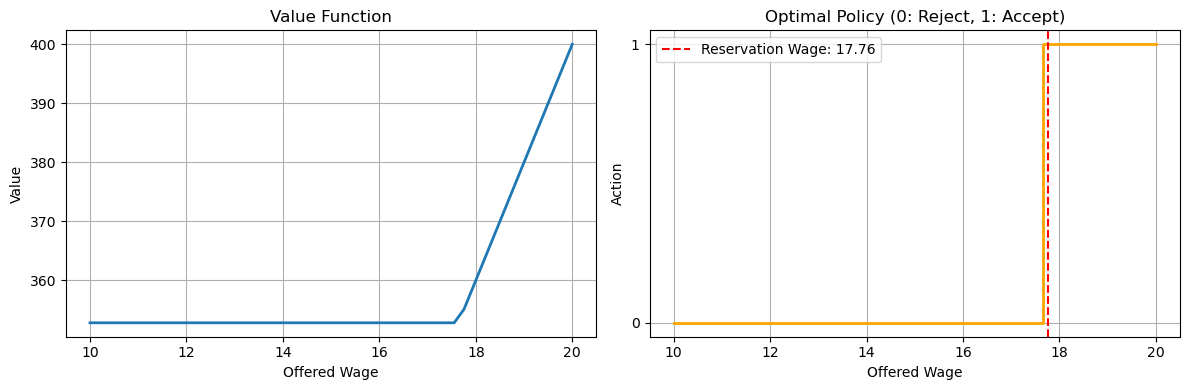

In [3]:
# 今回は、ジョブサーチモデルを離散的な状態空間で定式化し、QuanteconのDiscreteDPクラスを用いて最適政策を求める例を示します。
# 状態は提示される賃金の種類、行動は「拒否して探索を続ける」か「受諾して就職する」の2つです。
# https://python.quantecon.org/mccall_model.htmlも参考にしています。
import numpy as np
import quantecon as qe
import matplotlib.pyplot as plt

# 1. パラメータとグリッドの設定
n_w = 50                           # 提示される賃金の種類（状態の数）
w_grid = np.linspace(10, 20, n_w)  # 10から20までの賃金グリッド
p = np.ones(n_w) / n_w             # 各賃金が提示される確率（ここでは一様分布とする）
c = 12.0                           # 失業手当（探索中の報酬）
beta = 0.95                        # 割引因子

n_s = n_w                          # 状態数（現在の提示賃金）
n_a = 2                            # 行動数（0: 拒否して探索継続, 1: 受諾して就職）

# 2. 報酬行列 R と遷移確率行列 Q の構築
# R[状態, 行動], Q[現在の状態, 行動, 次の状態]
R = np.zeros((n_s, n_a))
Q = np.zeros((n_s, n_a, n_s))

for s in range(n_s):
    w = w_grid[s]  # 状態sに対応する現在の提示賃金
    
    # 行動0: 拒否 (Reject) した場合
    R[s, 0] = c              # 報酬は失業手当
    Q[s, 0, :] = p           # 次期の提示賃金は確率分布 p に従ってランダムに決まる
    
    # 行動1: 受諾 (Accept) した場合
    R[s, 1] = w              # 報酬は提示された賃金
    Q[s, 1, s] = 1.0         # 永久に同じ賃金をもらい続ける（確率1で状態sに留まる）

# 3. DiscreteDPによるモデルの計算
ddp = qe.markov.DiscreteDP(R, Q, beta)
res = ddp.solve(method='value_iteration')

# 4. 結果の解析と留保賃金（Reservation Wage）の特定
# res.sigma は各状態での最適行動。初めて受諾(1)に変わる賃金を探す
accept_indices = np.where(res.sigma == 1)[0]
reservation_wage = w_grid[accept_indices[0]] if len(accept_indices) > 0 else None

print("=== ジョブサーチモデル最適化結果 ===")
print(f"失業手当: {c}, 割引因子: {beta}")
print(f"留保賃金 (これ以上なら就職): {reservation_wage:.2f}")

# 5. 価値関数と最適政策の図示
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 価値関数のプロット (提示賃金ごとの生涯価値)
axes[0].plot(w_grid, res.v, linewidth=2)
axes[0].set_xlabel("Offered Wage")
axes[0].set_ylabel("Value")
axes[0].set_title("Value Function")
axes[0].grid(True)

# 最適政策のプロット (拒否するか受諾するかの境界線)
axes[1].step(w_grid, res.sigma, where='mid', color='orange', linewidth=2)
if reservation_wage:
    axes[1].axvline(x=reservation_wage, color='red', linestyle='--', 
                    label=f"Reservation Wage: {reservation_wage:.2f}")
axes[1].set_xlabel("Offered Wage")
axes[1].set_ylabel("Action")
axes[1].set_title("Optimal Policy (0: Reject, 1: Accept)")
axes[1].set_yticks([0, 1])
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()